# Femicide in Kenya: Time Series Forecasting

## Objective

This notebook focuses on **forecasting national-level femicide cases in Kenya**
using historical monthly data.

While earlier analysis explored trends, seasonality, and spatial patterns,
the goal here is to:

- Model temporal dynamics in femicide cases  
- Generate short- to medium-term forecasts  
- Assess whether reported cases show signs of growth, stabilization, or decline  

The forecasts produced are intended to be **exploratory and illustrative**, not
predictive of individual incidents.

---

## Scope and Limitations

This forecasting analysis is conducted at the **national level** and uses
**aggregated monthly case counts**.

Key limitations include:

- The data are sourced from media reports, not official crime registries  
- Reporting intensity may change over time, affecting observed trends  
- Forecasts assume historical patterns persist into the future  
- External factors (policy changes, social shocks) are not explicitly modeled  

As such, forecasts should be interpreted as **trend projections**, not precise
predictions of future femicide incidence.

---

## Data Preparation

The input dataset consists of a monthly time series with:

- A datetime index representing the month  
- A single variable (`cases`) representing total reported femicide cases  

All missing dates have been explicitly filled with zero counts to ensure
a continuous time series suitable for modeling.

---

## Forecasting Strategy

Multiple modeling approaches may be explored, including:

- Baseline statistical models (e.g. naive or moving average)  
- Decomposition-based models  
- Autoregressive models (e.g. ARIMA / SARIMA)  

Models are evaluated based on:

- Interpretability  
- Stability of forecasts  
- Ability to capture trend and seasonality  

The emphasis is on **clarity and transparency**, rather than model complexity.

---

## Evaluation Approach

Where possible, historical data are split into:

- A training period for model fitting  
- A validation period for assessing forecast behavior  

Evaluation focuses on:

- Visual comparison between actual and predicted values  
- Error metrics where applicable  
- Sensitivity of forecasts to model assumptions  

---

## Ethical Considerations

Forecasting femicide cases involves sensitive and traumatic subject matter.
This analysis is conducted with the understanding that:

- Each data point represents a loss of life  
- Forecasts should not be used to normalize or trivialize violence  
- Results must be communicated responsibly and with contextual nuance  

The purpose of this work is to support awareness, prevention, and informed
discussion—not deterministic conclusions.

---

## Next Steps

The following sections will:

- Fit baseline forecasting models  
- Compare alternative modeling approaches  
- Visualize future projections with uncertainty  

Subsequent project stages will integrate these forecasts into interactive
dashboards for exploration and communication.


### BASELINE MODEL

In [16]:
# Library importation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [17]:
# loadng the data(national monthly cases)
df = pd.read_csv('../Data/Processed/national_monthly_cases.csv', 
                parse_dates=['date'],
                index_col='date')
df.head(), df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 224 entries, 2005-05-01 to 2023-12-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   cases   224 non-null    int64
dtypes: int64(1)
memory usage: 3.5 KB


(            cases
 date             
 2005-05-01      1
 2005-06-01      0
 2005-07-01      0
 2005-08-01      0
 2005-09-01      0,
 None)

In [18]:
# Ensure the time series has a monthly frequency
df = df.asfreq("MS")

# Check for missing values
df.isna().sum()


cases    0
dtype: int64

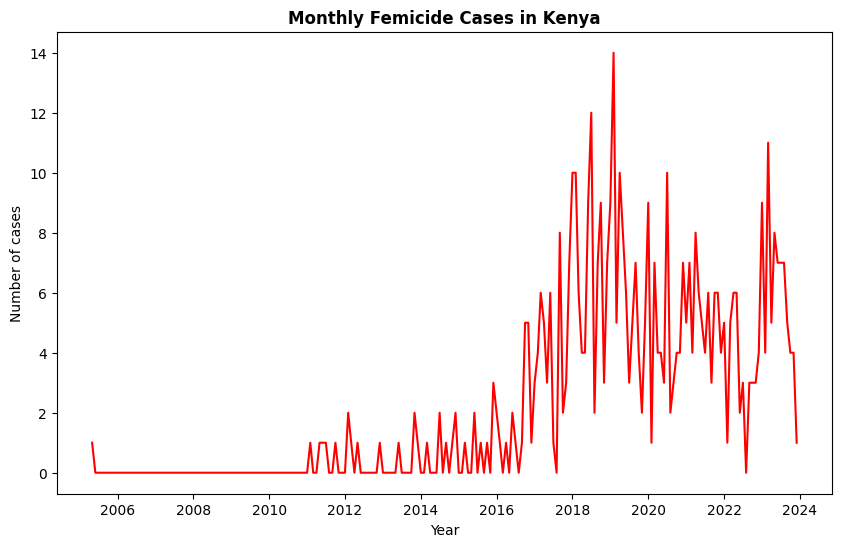

In [19]:
# Visual Inspection of the data
plt.figure(figsize=(10,6))
plt.plot(df.index, df['cases'], color = 'red')
plt.title('Monthly Femicide Cases in Kenya', weight = 'bold')
plt.xlabel('Year')
plt.ylabel('Number of cases')
plt.show()

In [20]:
# Split the data into train and test sets
# unlike traditional ML models we need to split the data chronologcally(last 12 months as the test set)
train = df.iloc[:-24]
test = df.iloc[-24:]

# chek the size
train.shape, test.shape

((200, 1), (24, 1))

## Baseline Model: Naïve Forecast

The baseline model assumes that the most recent observed value
will persist into the future.

For each month in the test period, the forecasted value is set equal
to the last observed value from the training data.

This naïve approach serves as a benchmark. Any advanced model
must outperform this baseline to justify its added complexity.


In [21]:
# Last observed value in the training set
last_observed = train["cases"].iloc[-1]

# Create naive forecast for the test period
naive_forecast = pd.Series(
    last_observed,
    index=test.index
)

naive_forecast.head()


date
2022-01-01    4
2022-02-01    4
2022-03-01    4
2022-04-01    4
2022-05-01    4
Freq: MS, dtype: int64

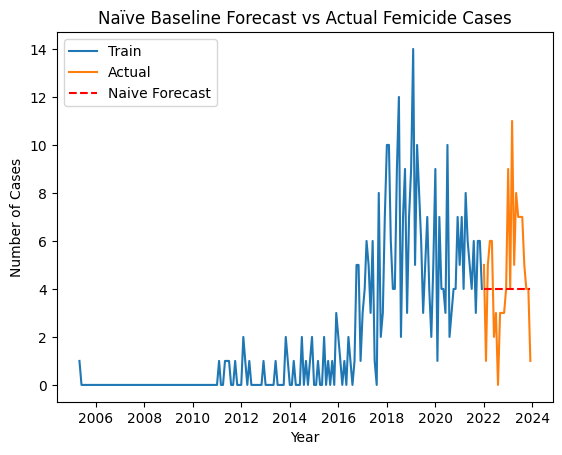

In [22]:
plt.figure()
plt.plot(train.index, train["cases"], label="Train")
plt.plot(test.index, test["cases"], label="Actual")
plt.plot(naive_forecast.index, naive_forecast, linestyle="--", label="Naive Forecast", color="red")

plt.title("Naïve Baseline Forecast vs Actual Femicide Cases")
plt.xlabel("Year")
plt.ylabel("Number of Cases")
plt.legend()
plt.show()


## Baseline Model Evaluation

To assess the performance of the naïve baseline model, forecasted values
are compared against the actual observations in the test period.

Evaluation focuses on:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

These metrics provide a quantitative reference point for judging whether
more complex time series models offer meaningful improvements.


In [23]:
# Calculate error metrics
mae = mean_absolute_error(test["cases"], naive_forecast)
rmse = np.sqrt(mean_squared_error(test["cases"], naive_forecast))

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")


MAE: 2.0416666666666665
RMSE: 2.669269563007828


## First Forecasting Model: ARIMA

Based on the presence of non-stationarity and a visible trend,
an ARIMA model is introduced as the first non-baseline forecasting approach.

An initial ARIMA configuration is selected to prioritize interpretability
over optimization.


In [24]:
# Importation
from statsmodels.tsa.arima.model import ARIMA

#fit the ARIMA model
arima_model = ARIMA(train['cases'], order = (1, 1, 1))
arima_results = arima_model.fit()

arima_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  cases   No. Observations:                  200
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -389.942
Date:                Mon, 26 Jan 2026   AIC                            785.884
Time:                        13:43:27   BIC                            795.764
Sample:                    05-01-2005   HQIC                           789.883
                         - 12-01-2021                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0664      0.057     -1.162      0.245      -0.178       0.046
ma.L1         -0.7914      0.037    -21.261      0.000      -0.864      -0.718
sigma2         2.9319      0.173     16.967      0.000       2.593       3.271
===================================================================================
Ljung-Box (L1) (Q):                   0.06   Jarque-Bera (JB):               150.83
Prob(Q):                              0.81   Prob(JB):                         0.00
Heteroskedasticity (H):             542.90   Skew:                             0.86
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.90
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

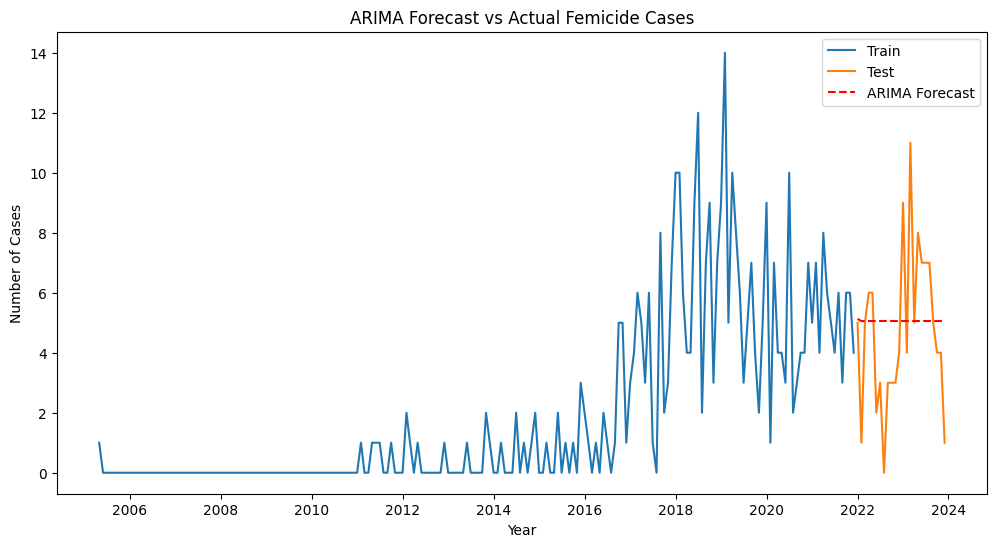

In [25]:
# Forcasting and Ploting
arima_forecast = arima_results.forecast(steps = len(test))
arima_forecast.index = test.index

# Plot comparison
plt.figure(figsize = (12, 6))
plt.plot(train.index, train['cases'], label = 'Train')
plt.plot(test.index, test['cases'], label = 'Test')
plt.plot(arima_forecast.index, arima_forecast, linestyle = '--', label = 'ARIMA Forecast', color = 'red')

plt.title("ARIMA Forecast vs Actual Femicide Cases")
plt.xlabel("Year")
plt.ylabel("Number of Cases")
plt.legend()
plt.show()

In [26]:
# Evaluation between ARIMA and Baseline
arima_mae = mean_absolute_error(test["cases"], arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test["cases"], arima_forecast))

arima_mae, arima_rmse

(2.0636165154101085, np.float64(2.5969665195452856))

### Interpretation of Model Comparison

The ARIMA model does not show a substantial improvement over the naïve
baseline in terms of MAE or RMSE.

This suggests that, at the national level, reported femicide cases exhibit
limited predictable structure beyond recent historical values.
The series appears to be dominated by short-term fluctuations rather than
strong seasonal or autoregressive patterns.

In this context, the naïve model provides a strong benchmark, and the lack
of significant improvement highlights the inherent unpredictability of
incident-driven social data.


#### Key Takeaways from ARIMA vs Baseline

**1. Univariate limitation:**
- The ARIMA model only sees historical femicide case counts.
- It cannot incorporate contextual information like social, economic, or demographic factors.

**2. Data-driven constraint:**
- Because the series is dominated by short-term fluctuations and noise, the ARIMA model doesn’t significantly outperform the naïve baseline.

**3. The value of additional features:**
- If you had extra dimensions (e.g., monthly social impact indicators, unemployment rates, police activity, media coverage), a multivariate approach (ARIMAX, Prophet with regressors, or ML models) could potentially capture patterns that the univariate model misses.

**4. Historical reliance:**
- With only case counts, forecasts rely heavily on recent historical values, which is why the naïve model was already surprisingly strong.

**Summary:**  
> ARIMA can improve predictions when meaningful additional information is available, 
> but with only past counts, the forecast is largely constrained to recent trends.